<a href="https://colab.research.google.com/github/SkyFlowTraveler/Fraud_Detection/blob/main/PetProject_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
from google.colab import files
import os
import shutil

uploaded = files.upload()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

shutil.copy(
    next(iter(uploaded)),
    os.path.expanduser("~/.kaggle/kaggle.json")
)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

Saving kaggle.json to kaggle (2).json


In [85]:

import kagglehub

path = kagglehub.dataset_download("miadul/credit-card-fraud-detection-dataset")

Using Colab cache for faster access to the 'credit-card-fraud-detection-dataset' dataset.


In [86]:
import pandas as pd
from pathlib import Path

path = Path("/root/.cache/kagglehub/datasets/miadul/credit-card-fraud-detection-dataset/versions/1")
csv_files = list(path.glob("*.csv"))

df = pd.read_csv(csv_files[0])

print(df.shape)

(10000, 10)


# EDA

In [87]:
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


## Видим, что Nan нету, 1 категориальный признак, проверим его распределение

In [89]:
df['merchant_category'].value_counts()

,count
merchant_category,
Food,2093
Clothing,2050
Travel,1990
Grocery,1944
Electronics,1923


## Признак сбалансирован. Проверим распределение target'а

In [90]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


## Несбалансированная выборка, будем использовать stratified, кроме того будем ориентироваться на Precision-Recall.

Проверим распределение остальных признаков

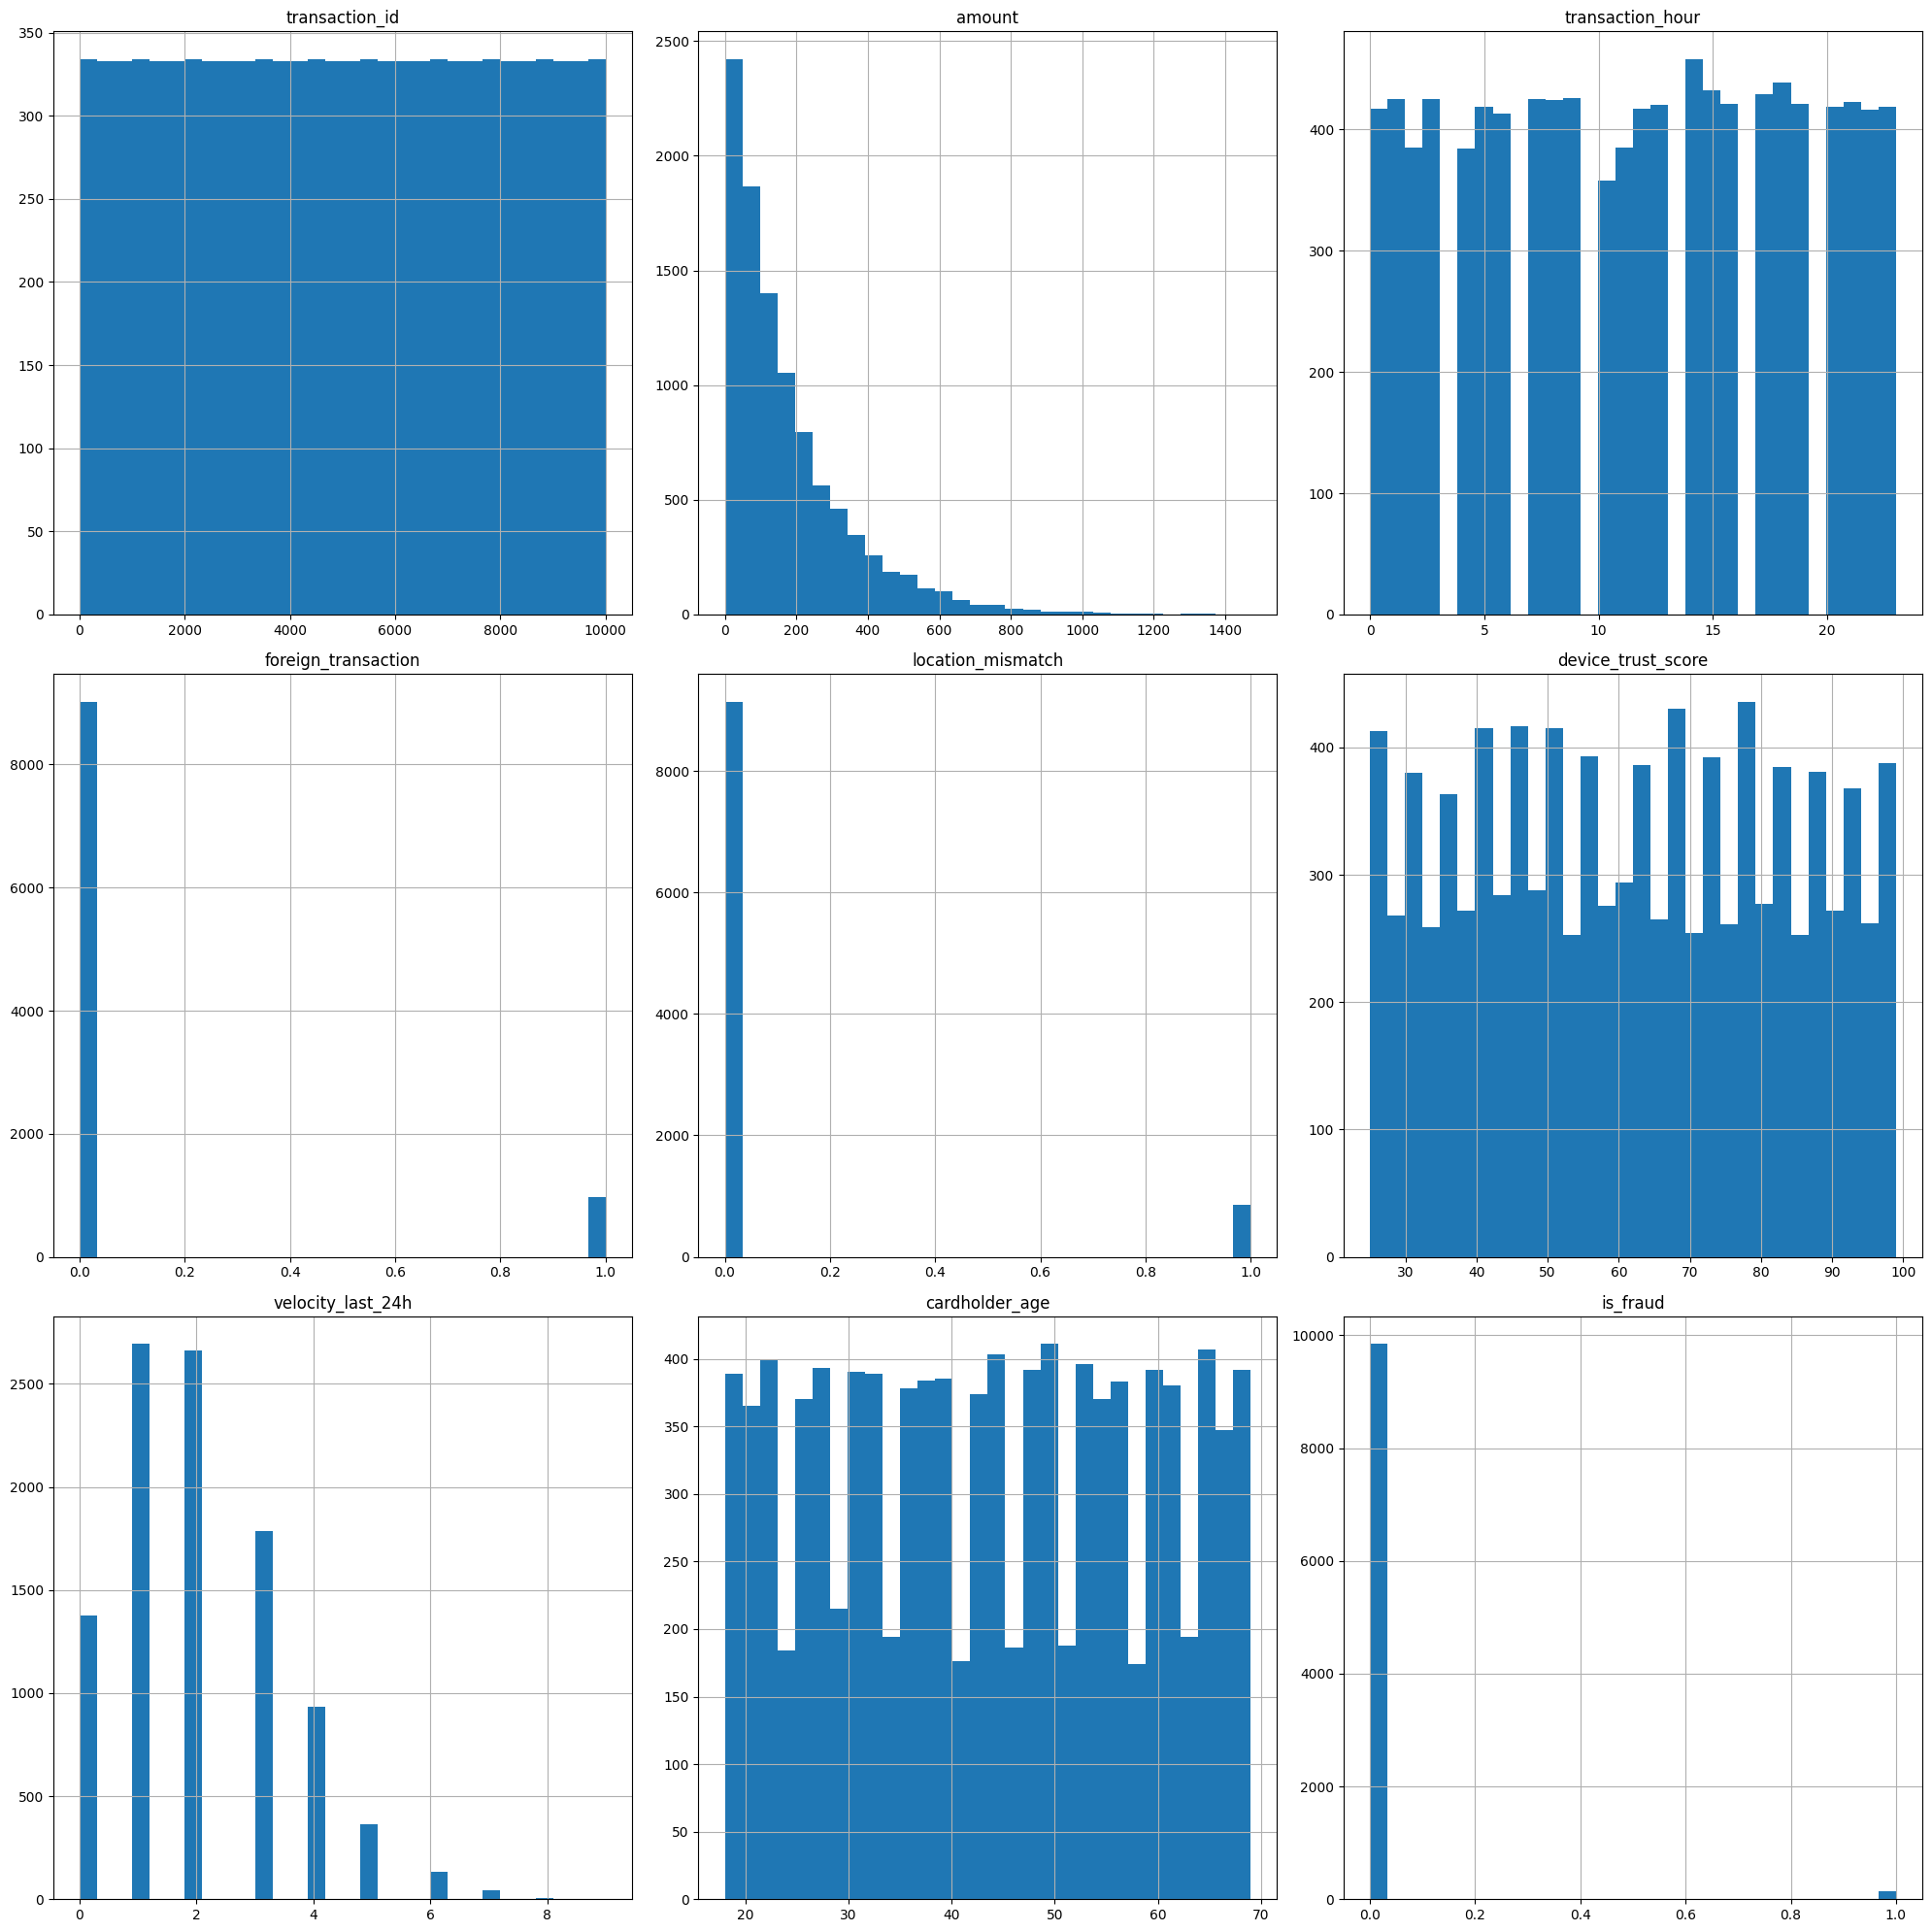

In [91]:
import matplotlib.pyplot as plt

df.hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

Видим возможную скоррелированность признаков foreign_transaction и location_mismatch

In [92]:
comparison = pd.crosstab(
    df["foreign_transaction"],
    df["location_mismatch"],
    rownames=["foreign_transaction"],
    colnames=["location_mismatch"]
)

print(comparison)

location_mismatch       0    1
foreign_transaction           
0                    8250  772
1                     893   85


Ок. Признаки несут разную информацию и не совпадают. Отлично.

In [93]:
fraud_by_category = pd.crosstab(
    df["merchant_category"],
    df["is_fraud"]
)

print(fraud_by_category)

is_fraud              0   1
merchant_category          
Clothing           2026  24
Electronics        1899  24
Food               2058  35
Grocery            1905  39
Travel             1961  29


Мы видим, что категории food и grocery дают больше риска мошеннической транзакции. Кодирование категорий вероятностью таргета может быть информативно

In [94]:
fraud_rate = (
    df.groupby("merchant_category")["is_fraud"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total",
          "sum": "fraud_count",
          "mean": "fraud_rate"
      })
)

fraud_rate["fraud_rate"] *= 100

print(fraud_rate)



fraud_rate["odds"] = (
    fraud_rate["fraud_count"] /
    (fraud_rate["total"] - fraud_rate["fraud_count"])
)

print(fraud_rate)

                   total  fraud_count  fraud_rate
merchant_category                                
Clothing            2050           24    1.170732
Electronics         1923           24    1.248050
Food                2093           35    1.672241
Grocery             1944           39    2.006173
Travel              1990           29    1.457286
                   total  fraud_count  fraud_rate      odds
merchant_category                                          
Clothing            2050           24    1.170732  0.011846
Electronics         1923           24    1.248050  0.012638
Food                2093           35    1.672241  0.017007
Grocery             1944           39    2.006173  0.020472
Travel              1990           29    1.457286  0.014788


fraud_rate - хороший вариант кодирования признака merchant_category. Теперь посмотрим именно мошеннические транзакции

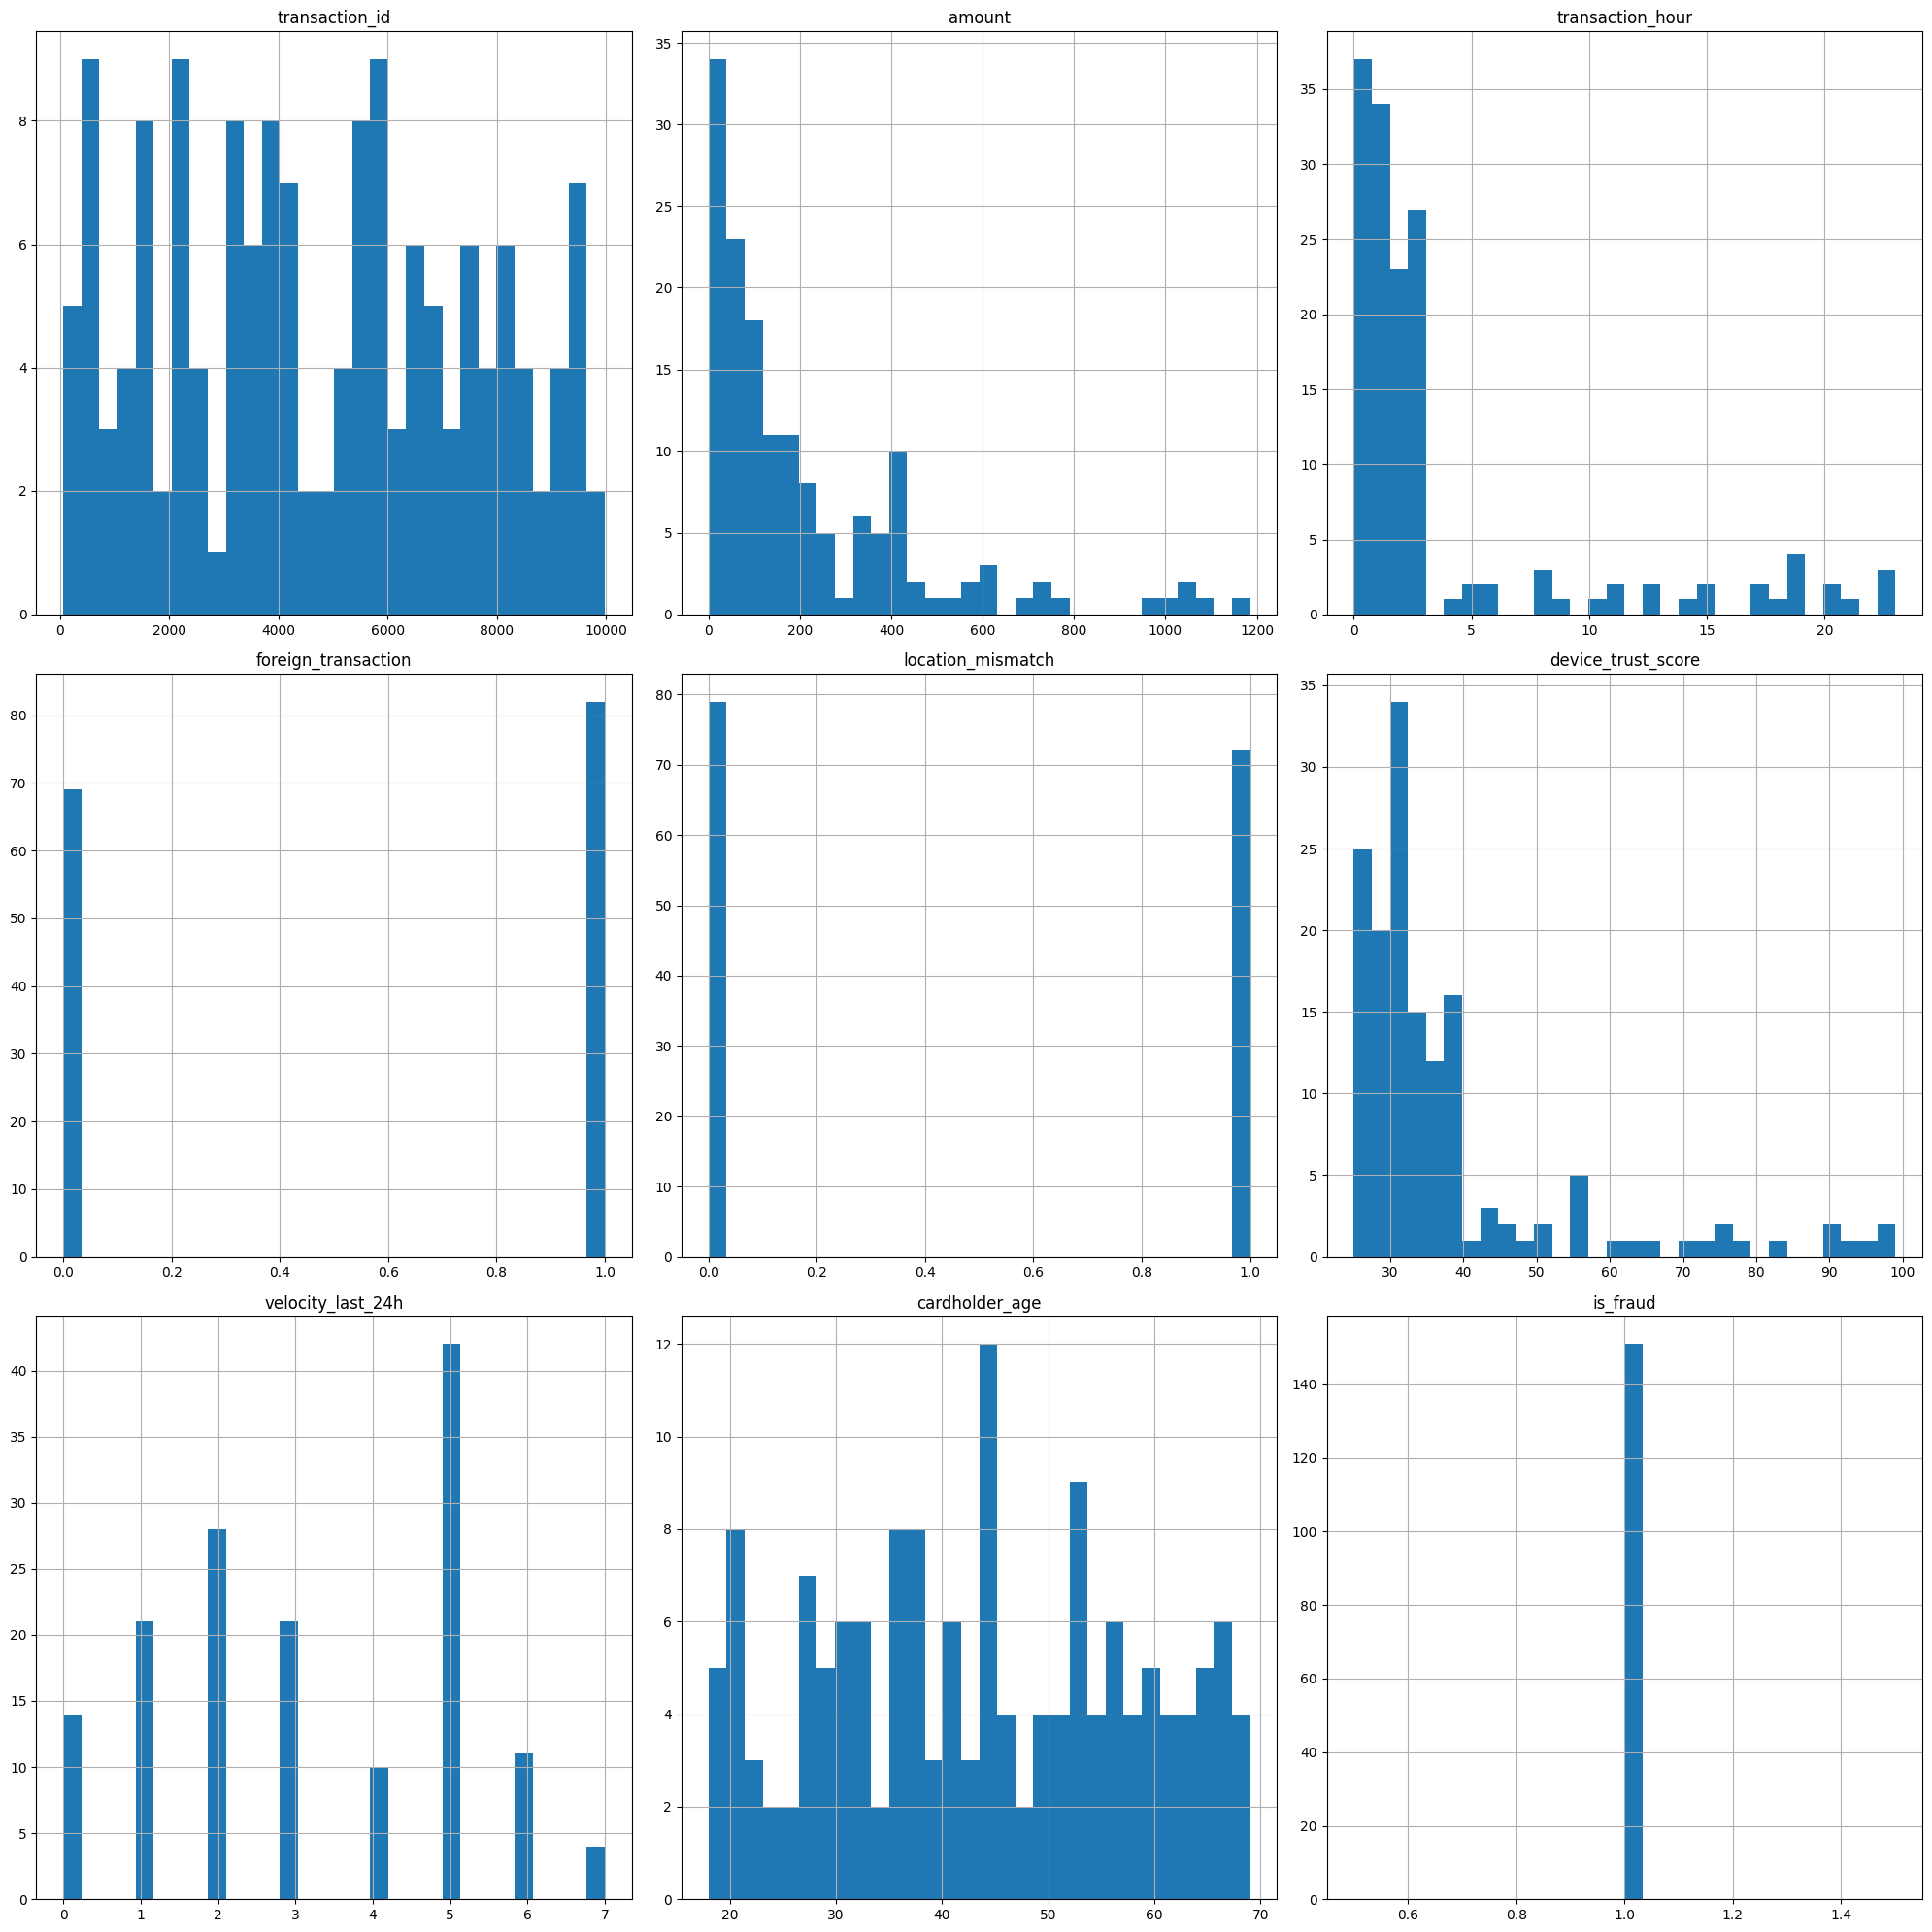

In [95]:
import matplotlib.pyplot as plt

df[df['is_fraud']==1].hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

Отсюда видно, что важными признаками являются:
- transaction_hour
- location_mismatch
- foreign_transaction
- device_trust_score
- velocity_last_24h
- cardholder_age(уже не так много информации)

Т.е. практически все признаки, что хорошо)

# Собственно, начнём подготовку данных

In [96]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_fraud','transaction_id'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=36
)

In [112]:
train = X_train.copy()
train['is_fraud'] = y_train

fraud_rate = train.groupby('merchant_category')['is_fraud'].mean()

X_train['merchant_category'] = (
    X_train['merchant_category'].map(fraud_rate)
)

X_test["merchant_category"] = (X_test["merchant_category"].map(fraud_rate))

print(fraud_rate)
X_train.head()

merchant_category
0.010949    0.010949
0.013029    0.013029
0.013767    0.013767
0.017190    0.017190
0.020833    0.020833
Name: is_fraud, dtype: float64


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
2010,2011,6.15,2,0.020833,0,0,73,0,52
6564,6565,30.28,0,0.010949,0,0,34,5,38
8178,8179,7.41,2,0.020833,0,0,76,3,23
7855,7856,98.40,8,0.020833,0,0,50,1,23
7235,7236,115.45,8,0.020833,0,0,39,5,43


In [98]:
X_train

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
2010,2011,6.15,2,0.020833,0,0,73,0,52
6564,6565,30.28,0,0.010949,0,0,34,5,38
8178,8179,7.41,2,0.020833,0,0,76,3,23
7855,7856,98.40,8,0.020833,0,0,50,1,23
7235,7236,115.45,8,0.020833,0,0,39,5,43
...,...,...,...,...,...,...,...,...,...
7919,7920,95.27,19,0.013029,0,0,41,3,26
6133,6134,14.52,14,0.013767,0,0,74,0,52
7929,7930,33.29,14,0.013767,0,1,89,1,31
7018,7019,79.32,1,0.010949,0,0,59,2,45


# Модели

In [99]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve
)

from xgboost import XGBClassifier

In [100]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [101]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    }

    print(f"\n{name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")


Logistic Regression
Precision: 0.2745
Recall:    0.9333
PR-AUC:    0.6828
ROC-AUC:   0.9912

Random Forest
Precision: 1.0000
Recall:    0.6000
PR-AUC:    0.9822
ROC-AUC:   0.9996

XGBoost
Precision: 1.0000
Recall:    0.9333
PR-AUC:    0.9775
ROC-AUC:   0.9990


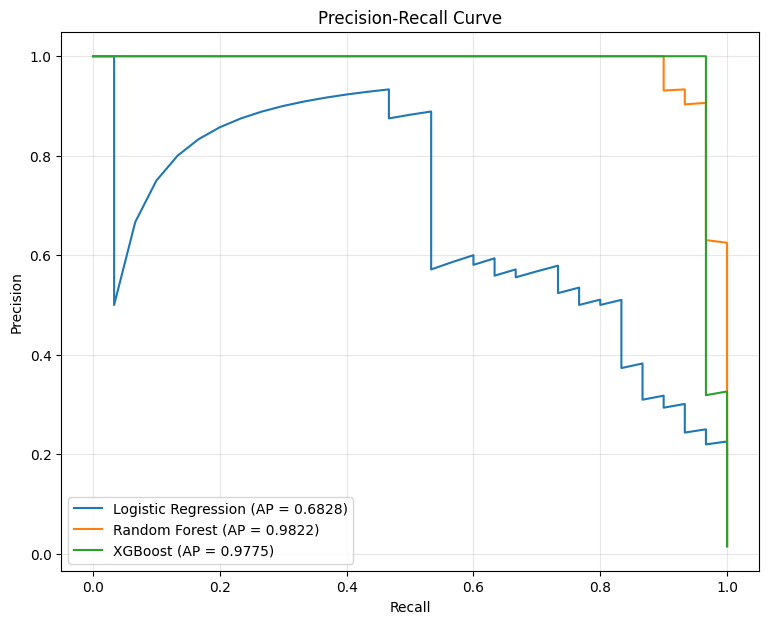

In [102]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(y_test, y_prob)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [103]:
results_df = (
    __import__("pandas")
    .DataFrame(results)
    .T
    .sort_values("PR-AUC", ascending=False)
)

results_df

,Precision,Recall,PR-AUC,ROC-AUC
Random Forest,1.00000,0.600000,0.982153,0.999619
XGBoost,1.00000,0.933333,0.977536,0.998951
Logistic Regression,0.27451,0.933333,0.682776,0.991151


# Результаты поражают, проверим на CrossValidation'е
EDA выделило много информативных признаков, так что результат может быть оправдан

In [104]:
df.groupby("is_fraud").mean(numeric_only=True).T.sort_values(
    by=1,
    ascending=False
).head(20)

is_fraud,0,1
transaction_id,5004.129861,4763.741722
amount,175.333015,216.182980
cardholder_age,43.469794,43.397351
device_trust_score,62.165804,37.867550
transaction_hour,11.712154,3.841060
velocity_last_24h,1.990557,3.205298
foreign_transaction,0.090974,0.543046
location_mismatch,0.079704,0.476821


Видим, действительно, огромную разницу в средних признаках у классов

In [108]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    models["Random Forest"],
    X_train,
    y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print(scores)
print(scores.mean())
print(scores.std())

[0.9594774  0.98319472 0.9787221  0.95941166 0.96705818]
0.9695728147573879
0.009805666281326748


Хотя результаты довольно оптимистичны из-за data leakage между фолдами по параметру merchant_category, мы можем увидеть, что даже случайный лес показывает неплохие результаты и результаты на тесте были вполне правдоподобны. Сделаем тоже самое, удалив merchant_category

In [109]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

target = "is_fraud"

X = df.drop(columns=[
    target,
    "transaction_id",
    "merchant_category"
])

y = df[target]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print(scores)
print(f"Mean PR-AUC: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

[0.99781362 0.99119769 1.         0.97202009 0.97968837]
Mean PR-AUC: 0.9881
Std: 0.0107


Т.к. даже без merchant_category CV показывает хороший результат, можем быть уверены, что data leakage не был причиной высокого результата

Проверим информативность признаков численно

In [110]:
for col in [
    "foreign_transaction",
    "location_mismatch"
]:
    print(f"\n{col}")
    print(
        pd.crosstab(
            df[col],
            df["is_fraud"],
            normalize="index"
        )
    )


foreign_transaction
is_fraud                    0         1
foreign_transaction                    
0                    0.992352  0.007648
1                    0.916155  0.083845

location_mismatch
is_fraud                  0         1
location_mismatch                    
0                  0.991360  0.008640
1                  0.915986  0.084014


In [111]:
from sklearn.metrics import roc_auc_score

for col in X.columns:
    if df[col].nunique() > 2:
        score = roc_auc_score(y, df[col])
        score = max(score, 1 - score)
        print(f"{col:25} {score:.4f}")

amount                    0.5134
transaction_hour          0.8252
device_trust_score        0.8267
velocity_last_24h         0.6792
cardholder_age            0.5013


# Итог
Мы видим множество информативных признаков, которые в совокупности позволяют агрегирующей модели выдать невероятно хороший результат